# EDA Overview

Quick exploratory analysis to understand:
- Revenue by country
- Orders by month
- Customer distribution

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean_retail.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# standard helper columns
df["Month"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

# order-level table (one row per invoice)
orders = (
    df.groupby("Invoice", as_index=False)
      .agg(
          OrderValue=("Revenue", "sum"),
          OrderDate=("InvoiceDate", "min"),
          CustomerID=("Customer ID", "first"),
          Country=("Country", "first")
      )
)
orders["OrderMonth"] = orders["OrderDate"].dt.to_period("M").dt.to_timestamp()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12-01


## Revenue by Country

In [17]:
country_revenue = (
    df.groupby("Country", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
)

country_revenue.head(15)

,Country,Revenue
34,United Kingdom,7414755.963
9,EIRE,356085.210
21,Netherlands,268786.000
12,Germany,202395.321
11,France,146215.420
29,Sweden,53171.390
8,Denmark,50906.850
28,Spain,47601.420
30,Switzerland,43921.390
0,Australia,31446.800


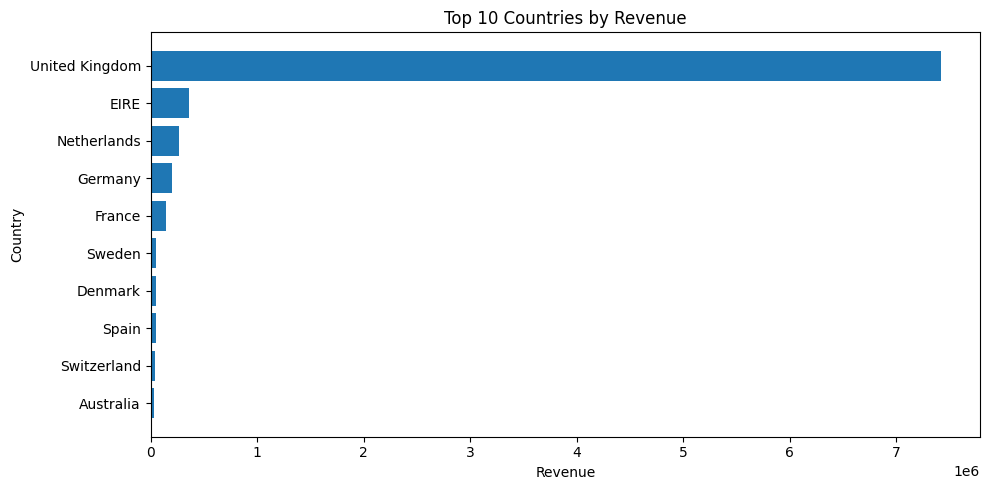

In [18]:
top_c = country_revenue.head(10).copy()

plt.figure(figsize=(10,5))
plt.barh(top_c["Country"], top_c["Revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Orders by Month

In [19]:
monthly_orders = (
    orders.groupby("OrderMonth", as_index=False)["Invoice"]
          .nunique()
          .rename(columns={"Invoice": "Orders"})
          .sort_values("OrderMonth")
)

monthly_revenue = (
    df.groupby("Month", as_index=False)["Revenue"]
      .sum()
      .rename(columns={"Month": "OrderMonth"})
      .sort_values("OrderMonth")
)

monthly_orders.head(), monthly_revenue.head()

(  OrderMonth  Orders
 0 2009-12-01    1512
 1 2010-01-01    1011
 2 2010-02-01    1104
 3 2010-03-01    1524
 4 2010-04-01    1329,
   OrderMonth     Revenue
 0 2009-12-01  686654.160
 1 2010-01-01  557319.062
 2 2010-02-01  506371.066
 3 2010-03-01  699608.991
 4 2010-04-01  594609.192)

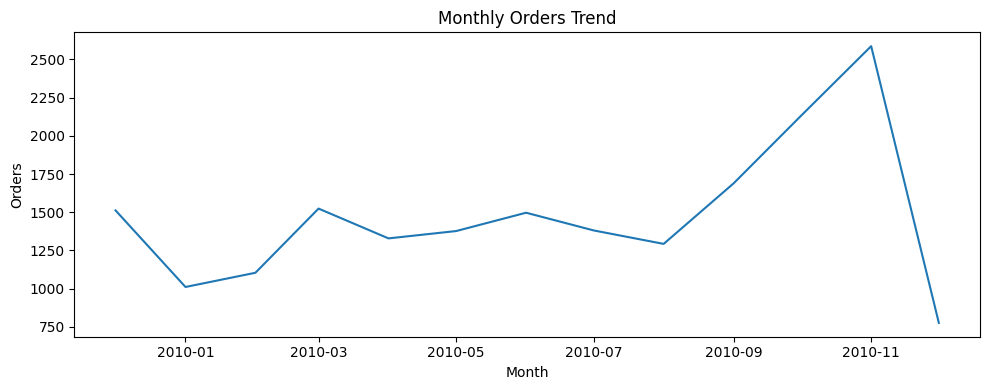

In [20]:
plt.figure(figsize=(10,4))
plt.plot(monthly_orders["OrderMonth"], monthly_orders["Orders"])
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

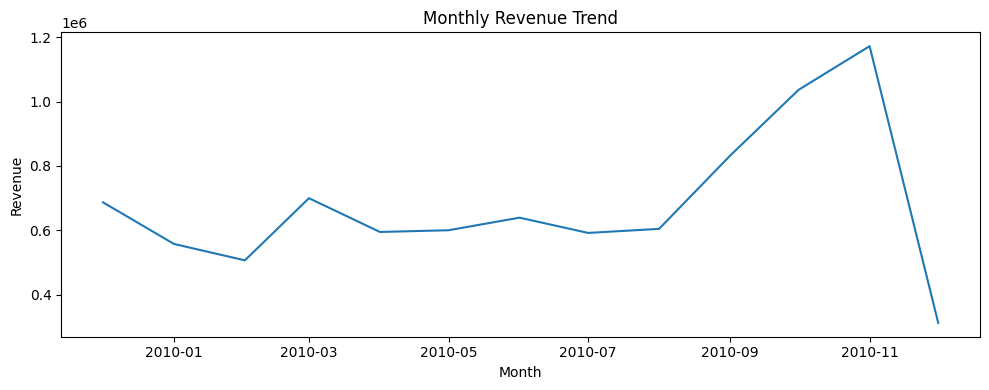

In [21]:
plt.figure(figsize=(10,4))
plt.plot(monthly_revenue["OrderMonth"], monthly_revenue["Revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Customer Distribution


In [22]:
customer = (
    orders.groupby("CustomerID", as_index=False)
          .agg(
              TotalSpend=("OrderValue", "sum"),
              Orders=("Invoice", "nunique"),
              FirstOrder=("OrderDate", "min"),
              LastOrder=("OrderDate", "max")
          )
)

customer["AvgOrderValue"] = customer["TotalSpend"] / customer["Orders"]
customer.head()

,CustomerID,TotalSpend,Orders,FirstOrder,LastOrder,AvgOrderValue
0,12346.0,372.86,11,2009-12-14 08:34:00,2010-06-28 13:53:00,33.896364
1,12347.0,1323.32,2,2010-10-31 14:20:00,2010-12-07 14:57:00,661.660000
2,12348.0,222.16,1,2010-09-27 14:59:00,2010-09-27 14:59:00,222.160000
3,12349.0,2671.14,3,2010-04-29 13:20:00,2010-10-28 08:23:00,890.380000
4,12351.0,300.93,1,2010-11-29 15:23:00,2010-11-29 15:23:00,300.930000


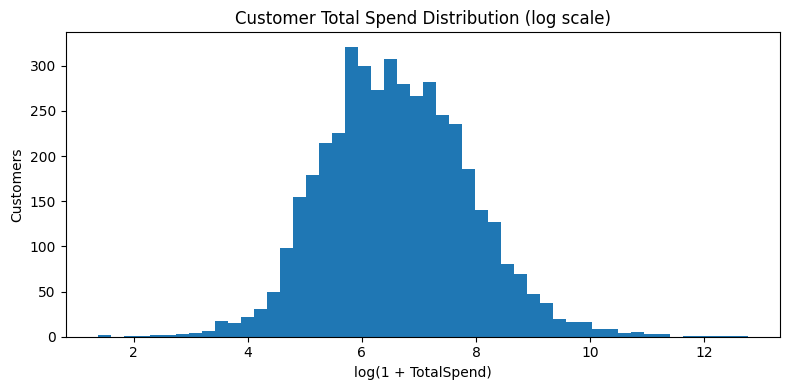

In [23]:
plt.figure(figsize=(8,4))
plt.hist(np.log1p(customer["TotalSpend"]), bins=50)
plt.title("Customer Total Spend Distribution (log scale)")
plt.xlabel("log(1 + TotalSpend)")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

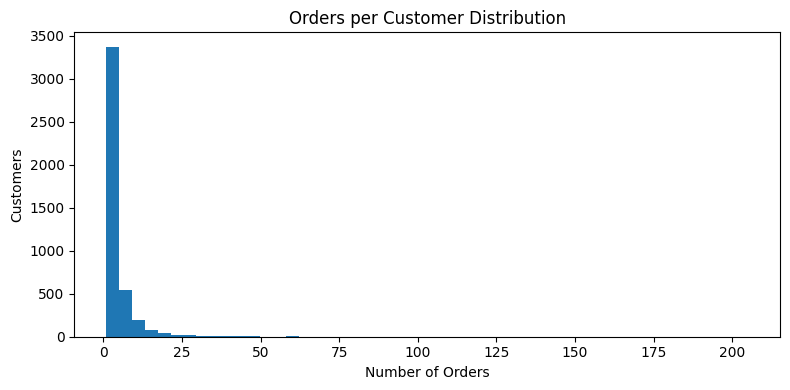

In [24]:
plt.figure(figsize=(8,4))
plt.hist(customer["Orders"], bins=50)
plt.title("Orders per Customer Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

In [25]:
customer_sorted = customer.sort_values("TotalSpend", ascending=False).copy()
customer_sorted["CumRevenueShare"] = customer_sorted["TotalSpend"].cumsum() / customer_sorted["TotalSpend"].sum()

top_10pct_n = int(np.ceil(0.10 * len(customer_sorted)))
top_10pct_share = customer_sorted.iloc[top_10pct_n-1]["CumRevenueShare"]

top_10pct_n, top_10pct_share

(432, np.float64(0.5987317850715729))